# HGM 等価熱補償 ΔT_max の感度 — catofin の転化率・生産量・TAC への効き

**狙い**: Catofin の単通転化率(~38%)は、HGM 等価熱補償が床温を $T_{in}-\Delta T_{max}$ 以上に維持することで
決まる(`reactor_conversion_ceiling.ipynb`)。この **$\Delta T_{max}$=50K は !仮置き**(再生蓄熱の許容温度降下)。
本ノートは $\Delta T_{max}$=30/50/80K を実走で振り、**単通転化率・生産量・TAC・feasibility** がどう動くかを示す。
catofin 設計点と原料 F_fresh は #227 で固定する(= HGM 仮定だけを動かす純感度)。

> $\Delta T_{max}$ が大きい(=HGM が弱い/床がより冷える)ほど転化率↓ → 生産量↓・リサイクル↑。
> $\Delta T_{max}$=50K(標準)が結果の前提。**この1つの !仮置きが TAC をどれだけ動かすか**を定量化する。
>
> ⚠️ Dist2=HYSYS のため VPN 必須・1点あたり数十秒。


In [1]:
import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
os.environ.setdefault('PDH_TRIAL_TIME_BUDGET_SEC', '300')
ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import main
import units.reactors.catofin as cat       # _DT_MAX_K を patch する
from flowsheet import evaluate
import json
best = json.load(open(os.path.join(ROOT, 'outputs', 'main_20260604_014318', 'best.json'), encoding='utf-8'))
p = best['params']; main.REACTOR_KIND = 'catofin'
F_fresh = float(p['F_C3H8_fresh_kmol_h'])
print(f'設計点 #227 固定, F_fresh={F_fresh:.0f} kmol/h.  標準 ΔT_max = {cat._DT_MAX_K:.0f} K')

設計点 #227 固定, F_fresh=1457 kmol/h.  標準 ΔT_max = 50 K


## ΔT_max を 30/50/80K で実走

In [2]:
def eval_at_dtmax(dtmax):
    old = cat._DT_MAX_K
    try:
        cat._DT_MAX_K = float(dtmax)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            r = evaluate(main._build_design(p), main._CONFIG, verbose=False,
                         apply_hi=True, hi_dT_min_K=10.0, apply_stage2=False,
                         F_C3H8_override=F_fresh)
    finally:
        cat._DT_MAX_K = old
    op = r.solver.one_pass if (r.solver and r.solver.one_pass) else {}
    rx = op.get('r_rx'); X = rx.performance.Conversion if rx and getattr(rx,'performance',None) else float('nan')
    Tout = rx.effluent.T_out_avg-273.15 if rx and getattr(rx,'effluent',None) else float('nan')
    sp = r.specs
    prod = sp.production_kmol_h if sp else float('nan')
    tac_hi = r.economics_hi.TAC if r.economics_hi else float('nan')
    return dict(dtmax=dtmax, X=round(X,1), Tout=round(Tout,0), prod=round(prod,0) if prod==prod else prod,
                eff_TAC=round(r.effective_TAC,1), feas=r.is_feasible,
                unit=r.failure_unit)

rows = [eval_at_dtmax(d) for d in (30, 50, 80)]
df = pd.DataFrame(rows)
print(df.to_string(index=False))

 dtmax    X   Tout   prod  eff_TAC  feas    unit
    30  0.0 -273.0    NaN   5107.3 False    r_rx
    50 37.8  608.0 1194.0   1092.8  True success
    80 29.2  579.0 1194.0   1122.8  True success


C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30444\3489702420.py:18: UserWarning: Glyph 20740 (\N{CJK UNIFIED IDEOGRAPH-5104}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30444\3489702420.py:18: UserWarning: Glyph 20870 (\N{CJK UNIFIED IDEOGRAPH-5186}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\yuish\AppData\Local\Temp\claude\ipykernel_30444\3489702420.py:18: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20740 (\N{CJK UNIFIED IDEOGRAPH-5104}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Z:\pdh_simulator\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20870 (\N{CJK UNIFIED IDEOGRAPH-5186}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(by

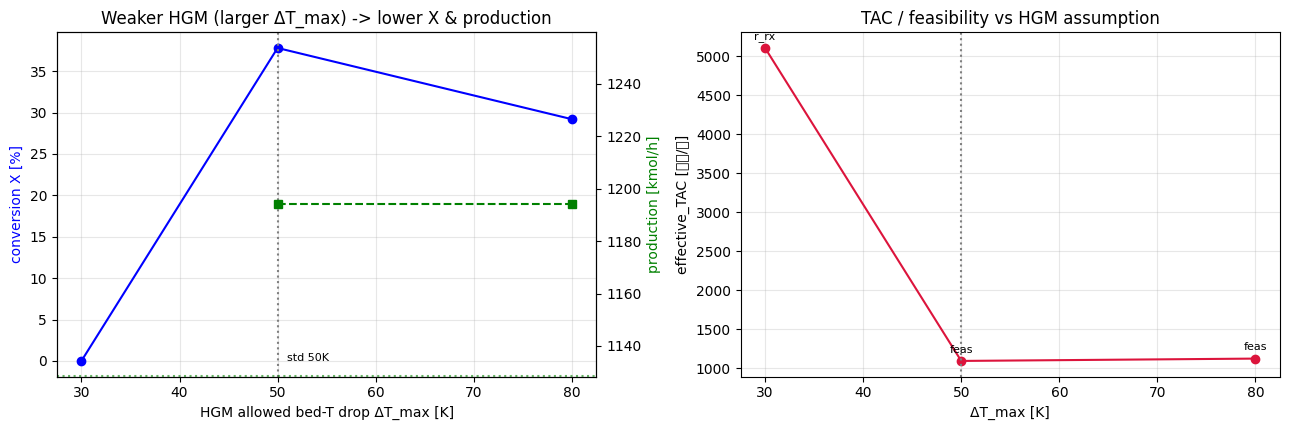

読み: ΔT_max が大きい(HGM 弱)ほど床が冷えて X↓ → 生産量↓。F_fresh 固定だと生産下限を割ると
penalty で effective_TAC が跳ねる。標準 50K の前提が結果(TAC/feasibility)をどれだけ左右するかが分かる。


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
ax[0].plot(df.dtmax, df.X, 'o-', color='blue', label='single-pass X [%]')
ax2 = ax[0].twinx(); ax2.plot(df.dtmax, df['prod'], 's--', color='green', label='production [kmol/h]')
ax2.axhline(1188*0.95, ls=':', color='green', alpha=0.6)
ax[0].axvline(50, ls=':', color='gray'); ax[0].text(51, df.X.min(), 'std 50K', fontsize=8)
ax[0].set_xlabel('HGM allowed bed-T drop ΔT_max [K]'); ax[0].set_ylabel('conversion X [%]', color='blue')
ax2.set_ylabel('production [kmol/h]', color='green')
ax[0].set_title('Weaker HGM (larger ΔT_max) -> lower X & production'); ax[0].grid(alpha=0.3)

feas = df[df.eff_TAC < 9000]
ax[1].plot(df.dtmax, df.eff_TAC, 'o-', color='crimson')
for _, r in df.iterrows():
    ax[1].annotate('feas' if r.feas else r.unit, (r.dtmax, r.eff_TAC), fontsize=8,
                   xytext=(0,6), textcoords='offset points', ha='center')
ax[1].axvline(50, ls=':', color='gray')
ax[1].set_xlabel('ΔT_max [K]'); ax[1].set_ylabel('effective_TAC [億円/年]')
ax[1].set_title('TAC / feasibility vs HGM assumption'); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('読み: ΔT_max が大きい(HGM 弱)ほど床が冷えて X↓ → 生産量↓。F_fresh 固定だと生産下限を割ると')
print('penalty で effective_TAC が跳ねる。標準 50K の前提が結果(TAC/feasibility)をどれだけ左右するかが分かる。')

## 結論

- Catofin の転化率・生産量は **HGM の床温維持力($\Delta T_{max}$)に直結**する。$\Delta T_{max}$ を大きく(HGM を弱く)
  すると床が冷えて単通転化率が下がり、F_fresh 固定では生産量が低下する。
- $\Delta T_{max}$=50K は **!仮置き**。本ノートで「この1仮定が TAC/feasibility をどれだけ動かすか」を定量化した。
- レポートには $\Delta T_{max}$ の根拠(再生蓄熱・酸化還元の熱収支)と、感度幅(本ノートの表)を明記すべき。
  より厳密には各 $\Delta T_{max}$ で再最適化(F_fresh 等を動かす)すれば真の TAC 感度が出る(本ノートは設計固定の純感度)。
